# LPT on the past light cone

The same 2LPT realization, evaluated at a single time (a = 1) and on the
observer's past light cone. On the light cone every Lagrangian point q is
displaced to the time $a_{\rm lc}$ at which it crosses the cone,

$$\chi(a_{\rm lc}) = \chi\big(\,|q + \psi(q, a_{\rm lc}) - x_{\rm obs}|\,\big),$$

so distant particles are seen earlier, less clustered, and at higher redshift.
The observer is stationary at the box centre, `observer = (0.5, 0.5, 0.5)`.
The box is not replicated, so shells are complete out to L/2.

In [6]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from cobox import Box, GRFSampler, IsoModeMask, Particles, ScalarField
from colcdm import Cosmology, LinearMatterPowSpec, LPT

N, L = 256, 1000.0

box = Box(N=N, L=L, D=3)
cosmology = Cosmology.from_preset("planck18")
pk = LinearMatterPowSpec(
    transfer_kind="symbolic_pofk",
    growth_kind="symbolic_pofk",
    cosmology=cosmology,
)
grf = GRFSampler(
    kind="complex",
    complex_base="cartesian",
    restrictions=IsoModeMask("nyquist_open"),
)
delta_naught = grf.sample_from_seed(42, box, pk)

In [4]:
lpt = LPT(delta_naught, order=2)

In [18]:
observer = (0.5,) * 3

psi = lpt.get_psi_rsd(a=1.0, cosmology=cosmology, observer=observer)
a_lc, psi_lc = lpt.get_psi_lc(
    cosmology, observer=observer, rsd=True, method="iterative", n_iter=2
)

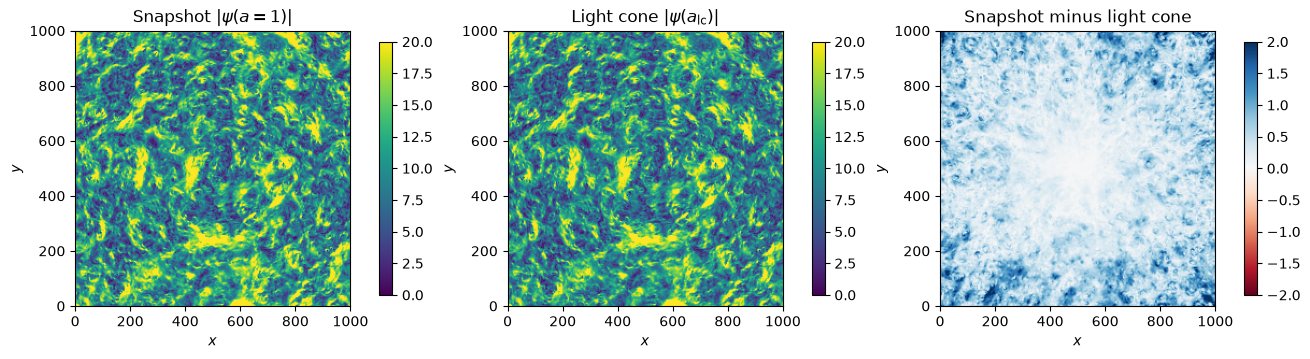

In [26]:
psi_norm = psi.norm()
psi_lc_norm = psi_lc.norm()

view = {"axis": 2, "slab": N // 2}

fig, axs = plt.subplots(1, 3, figsize=(13, 4.5), layout="constrained")

psi_norm.paint(ax=axs[0], **view, vmin=0, vmax=20, title=r"Snapshot $|\psi(a=1)|$")
psi_lc_norm.paint(
    ax=axs[1], **view, vmin=0, vmax=20, title=r"Light cone $|\psi(a_{\rm lc})|$"
)
(psi_norm - psi_lc_norm).paint(
    ax=axs[2],
    **view,
    cmap="RdBu",
    vmin=-2,
    vmax=2,
    title="Snapshot minus light cone",
)

plt.show()

PaintResult(fig=<Figure size 1000x450 with 2 Axes>, ax=<Axes: title={'center': 'Lightcone'}, xlabel='x0', ylabel='x1'>, mappable=<matplotlib.collections.PathCollection object at 0x70eadc7f6cc0>)

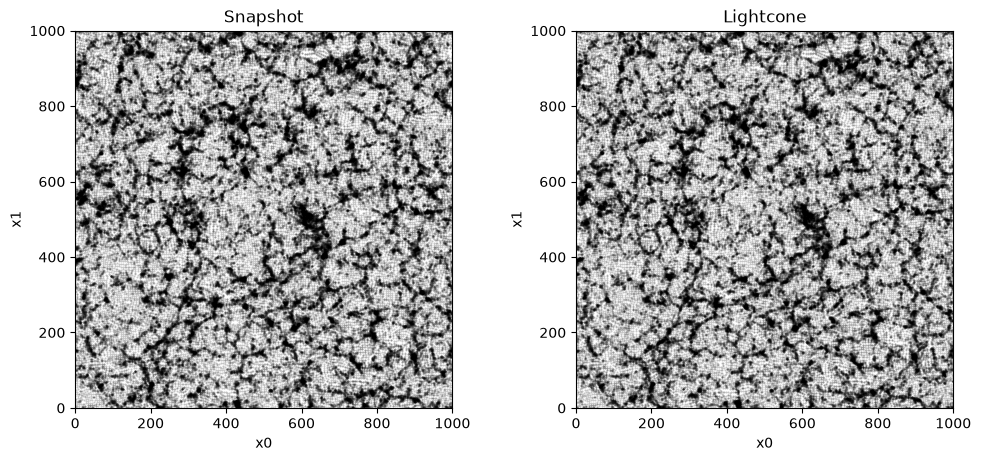

In [47]:
particles = Particles(psi.box)

x = particles.displace_from_vector_field(psi, interpolation=None)
x_lc = particles.displace_from_vector_field(psi_lc, interpolation=None)

slab, width = N // 3, 2
first = slab - width // 2
particle_slab = (first - 0.5, first + width - 0.5)  # cell units

view = {"axis": 2, "slab": particle_slab, "alpha": 0.2, "s": 0.3, "c": "k"}
fig, axs = plt.subplots(1, 2, figsize=(10, 4.5), layout="constrained")

x.paint(ax=axs[0], **view, title=r"Snapshot")
x_lc.paint(ax=axs[1], **view, title=r"Lightcone")